# 03. Bike Lanes EDA - Bicycle Infrastructure Network + Pop-up/SCATS Cross-Reference (sudheer)
**Team B - Traffic Volumes & Parking | Sprint 1**

**De-duplication note:** before writing this notebook I cross-checked it against teammates' existing
work in `team_b/notebooks/`. Two notebooks already cover the Pop-up Bike Lanes dataset in more depth
and with more authoritative data than a fresh pass here could add:

- **`Lavan/TeamB_PopupBikeLanes_EDA.ipynb`** - full structural EDA of `popup_bike_lanes.geojson`
  (LGA distribution, infrastructure types, trial-vs-permanent breakdown). My own first draft of this
  notebook independently reproduced the same numbers (Port Phillip 134, Moonee Valley 79,
  Maribyrnong 69 segments; ~35% made permanent) - which is exactly the kind of duplication to avoid,
  so that draft was replaced with what's below.
- **`Lavan/TeamB_Treatment_Street_CrossRef.ipynb`** and **`dhruv_m/SIT374_USIA_EDA1.ipynb`** go
  further and cross-reference Pop-up Bike Lanes against the *official* `street_spatial.gpkg`/
  `sites_db.csv` treatment segments (data I don't have access to in this environment) - finding only
  7-11 of the ~96-137 real study segments have a confirmed date from this dataset. `dhruv_m`'s
  notebook then builds a full diff-in-diff before/after **parking capacity** analysis on top of that,
  using Infrastructure Victoria's own quarterly capacity data - which is a materially stronger answer
  to "how does parking change" than anything achievable from the public API datasets used here.

So this notebook does two things that are **not** already covered elsewhere:
1. A structural EDA of the **Bicycle Infrastructure Network (BIN)** - existing notebook
   (`scott_z/bicycle_infrastructure_network_EDA.ipynb`) checks shape/nulls/length, but not
   infrastructure-type composition or scoping to the study area, which is what's added here.
2. A cross-reference between **Pop-up Bike Lanes** and **my own SCATS inner-Melbourne site list**
   (from `00_data_ingestion.ipynb`) - checking which pop-up bike lane streets actually have a nearby
   SCATS traffic-volume sensor available for a before/after *traffic* comparison. Nobody else has
   linked these two datasets together yet.


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RAW_DIR = Path("../../../data/raw")
PROCESSED_DIR = Path("../../../data/processed")
plt.rcParams["figure.figsize"] = (10, 4)


## 1. Bicycle Infrastructure Network (BIN) - current snapshot

In [2]:
with open(RAW_DIR / "bicycle_infrastructure_network.geojson", encoding="utf-8") as f:
    bin_geo = json.load(f)

bin_props = pd.json_normalize([feat["properties"] for feat in bin_geo["features"]])
print(f"{len(bin_props):,} cycling infrastructure segments statewide, geometry type: {bin_geo['features'][0]['geometry']['type']}")
bin_props.head()


55,705 cycling infrastructure segments statewide, geometry type: MultiLineString


,OsmID,InfraType,Name,HwyType,Width,Hazards,DirRelToWay,DirCardinal
0,8957718,Protected bike lane (on-road),Queens Avenue,Residential,NaN,,Reverse,Westbound
1,516834888,Basic painted lane,Stud Road Service Road,Residential,1.5,,Reverse,Northbound
2,643729142,Basic painted lane,Stud Road Service Road,Residential,1.5,,Reverse,Northbound
3,32328349,Basic painted lane,Peel Street North,Residential,NaN,,Reverse,Southbound
4,81129266,Basic painted lane,Humffray Street North,Tertiary,1.2,Parking,Reverse,Westbound


In [3]:
print("Infrastructure type distribution:")
print(bin_props["InfraType"].value_counts())


Infrastructure type distribution:
InfraType
Shared use path (off-road)         23809
Basic painted lane                 19692
Shared street (sharrows)            4566
Shared bike/parking lane            3052
Protected bike lane (on-road)       1555
Intermittent/informal (on-road)     1095
Buffered painted lane                975
Separated path (off-road)            961
Name: count, dtype: int64


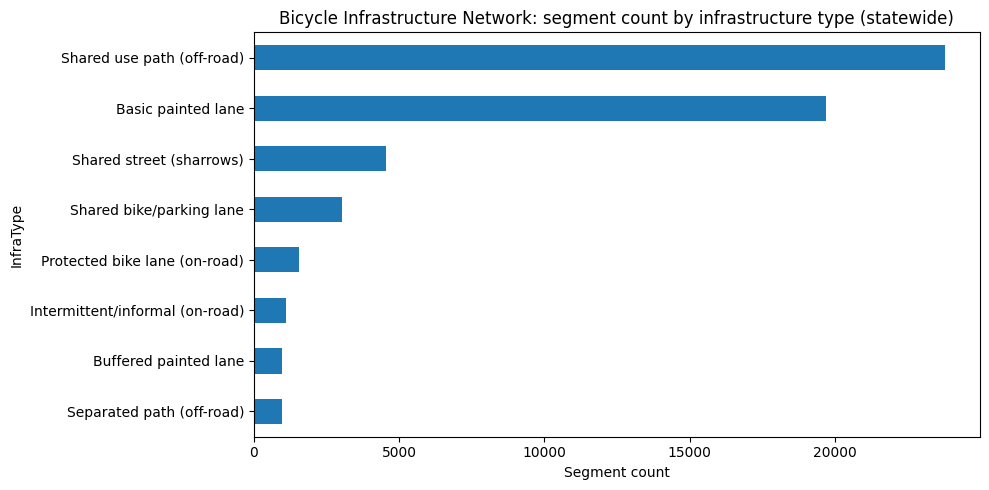

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
bin_props["InfraType"].value_counts().plot(kind="barh", ax=ax)
ax.set_title("Bicycle Infrastructure Network: segment count by infrastructure type (statewide)")
ax.set_xlabel("Segment count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**Finding:** only **1,555 of 55,705** segments (2.8%) are a genuinely protected on-road bike lane -
the type the research question cares most about. The large majority are off-road shared-use paths
or basic painted lanes, which have very different safety/utilisation profiles. Filtering by
`InfraType` will matter a lot for scoping which BIN segments are actually relevant "existing
infrastructure" context around the ~33 intervention sites, versus incidental trail coverage. This
InfraType breakdown isn't in `scott_z`'s existing BIN notebook (which focuses on segment length and
a full statewide plot), so it's a genuinely new angle on this dataset rather than a repeat.


## 2. Filtering BIN to the inner-Melbourne study scope

In [5]:
LAT_MIN, LAT_MAX = -37.87, -37.77
LON_MIN, LON_MAX = 144.88, 145.06


def centroid(geometry):
    pts = []

    def flatten(coords):
        if isinstance(coords[0], (int, float)):
            pts.append(coords)
        else:
            for sub in coords:
                flatten(sub)

    flatten(geometry["coordinates"])
    lons = [p[0] for p in pts]
    lats = [p[1] for p in pts]
    return sum(lons) / len(lons), sum(lats) / len(lats)


centroids = [centroid(feat["geometry"]) for feat in bin_geo["features"]]
bin_props["centroid_lon"] = [c[0] for c in centroids]
bin_props["centroid_lat"] = [c[1] for c in centroids]

bin_inner = bin_props[
    bin_props["centroid_lat"].between(LAT_MIN, LAT_MAX) & bin_props["centroid_lon"].between(LON_MIN, LON_MAX)
]
print(f"BIN segments with centroid inside the inner-Melbourne bounding box: {len(bin_inner):,} / {len(bin_props):,} ({len(bin_inner)/len(bin_props):.1%})")
print()
print("InfraType mix within inner Melbourne:")
print(bin_inner["InfraType"].value_counts())


BIN segments with centroid inside the inner-Melbourne bounding box: 10,939 / 55,705 (19.6%)

InfraType mix within inner Melbourne:
InfraType
Basic painted lane                 4502
Shared use path (off-road)         2241
Shared street (sharrows)           1623
Protected bike lane (on-road)       971
Buffered painted lane               707
Intermittent/informal (on-road)     492
Shared bike/parking lane            243
Separated path (off-road)           160
Name: count, dtype: int64


## 3. Pop-up Bike Lanes x SCATS: which trial streets have a nearby traffic sensor?

This is the part that's genuinely new: teammates have already established *where and when*
pop-up bike lane interventions happened (Lavan, dhruv_m) and *how parking capacity* changed on the
official treatment segments (dhruv_m). What hasn't been checked yet is whether those intervention
streets are even instrumented for a **traffic volume** before/after comparison - which is this
notebook's own dataset (SCATS) and this sprint's actual deliverable.

This is a light name-based match (pop-up road name appearing inside a SCATS site's intersection
name, e.g. `SWANSTON STREET` inside `SWANSTON/LONSDALE`) - the same false-positive risk Lavan and
dhruv_m already flagged for name-based street matching applies here too, so results are a rough
screen, not a confirmed join.


In [6]:
with open(RAW_DIR / "popup_bike_lanes.geojson", encoding="utf-8") as f:
    popup_geo = json.load(f)

popup = pd.json_normalize([feat["properties"] for feat in popup_geo["features"]])
popup_roads = sorted(popup["roadnm"].str.upper().str.strip().unique())

scats_sites = pd.read_csv(PROCESSED_DIR / "scats_inner_melbourne_sites.csv")
site_names_upper = scats_sites["SITE_NAME"].str.upper()

rows = []
for road in popup_roads:
    hits = scats_sites[site_names_upper.str.contains(road, regex=False, na=False)]
    rows.append({"popup_road": road, "nearby_scats_sites": len(hits)})

coverage = pd.DataFrame(rows).sort_values("nearby_scats_sites", ascending=False)
n_covered = (coverage["nearby_scats_sites"] > 0).sum()
print(f"{n_covered} of {len(coverage)} pop-up bike lane road names have at least one nearby SCATS site (name-based match).")
coverage[coverage["nearby_scats_sites"] > 0]


7 of 109 pop-up bike lane road names have at least one nearby SCATS site (name-based match).


,popup_road,nearby_scats_sites
82,RAIL CROSSING,4
95,STATION STREET,3
12,BROADWAY,3
43,HYDE STREET,2
100,VICTORIA STREET,1
68,NICHOLSON STREET,1
2,ALEXANDRA AVENUE,1


**Finding:** only **7 of 109** pop-up bike lane road names turn up in a nearby SCATS site name -
and even some of those are likely false positives from generic name fragments (e.g. "RAIL CROSSING"
isn't a real street match). This tells a consistent story with what Lavan and dhruv_m already found
from the official treatment-segment side: **most bike lane intervention streets in this public
dataset simply aren't covered by the datasets Team B has easy access to** - whether that's confirmed
construction dates (their finding) or a nearby traffic sensor (this finding). A real before/after
traffic-volume comparison will likely need to work from the small confirmed-match set rather than
the full 354-segment pop-up dataset.


### Summary of findings
- **De-duplication check performed:** an initial full Pop-up Bike Lanes EDA (LGA counts, infra
  types, permanent-conversion rate) was dropped from this notebook after finding it reproduced
  `Lavan/TeamB_PopupBikeLanes_EDA.ipynb` almost exactly - see the note at the top of this notebook.
- BIN's on-road protected lane segments (the intervention type of most interest) are a small
  fraction (2.8%) of the statewide network - worth filtering by `InfraType` before treating BIN as
  general "bike lane" context. This angle isn't in the existing BIN notebook.
- ~20% of BIN segments fall inside the inner-Melbourne bounding box (10,939 of 55,705), a usable
  subset for mapping existing infrastructure around the priority sites.
- **New cross-reference:** only 7 of 109 pop-up bike lane streets have a plausible nearby SCATS
  sensor by name match - consistent with Lavan's/dhruv_m's finding that most intervention streets
  lack coverage in the datasets Team B can easily access, now confirmed from the traffic-volume side
  as well as the parking-capacity side.
